# Is the payment acquirer market compressing? An analysis of the acquirer discount rate and the interchange fee

**Concepts**:

- merchant discount rate: Is the fee that acquirers or payment facilitaros apply to merchant tranasctions for processing their payments, 

- Interchange fee: is the fee that the acquirer pays to the card issuer for processing the card transaction 

- The difference betwen both represent a proxy of the gross spread that acquirers make,:

    Acquiring Spread = Mertchant discount rate - interchange fee

    That difference do not represnt a direct profit since it does not account several other costs (processing costs, fraud engines, etc) 



## BCRP Weighted-Average Methodology

source: [GUIA METODOLÓGICA PARA EL REPORTE DE TASAS DE DESCUENTO](https://www.bcrp.gob.pe/docs/Transparencia/Normas-Legales/Circulares/2022/circular-0027-2022-bcrp-guia.pdf)

- First is calculated a implicit merchant discount rate for each active merchant like:

Implicit MDR = Fees charged to the merchant / Transaction value

- then is calculated a weighted average using each merchant’s transaction value as its weight:

Weighted-average MDR = Σ(Implicit MDR × Transaction value) / Σ(Transaction value)

- According to the source,  calculation is performed within combinations of merchant segment, payment channel, card network, and card type. So, merchants with a higher transaction value will pressent greater influence on the reported rate

- It is like saying "per each 100 soles in the market , how much was charged by the acquirers?" or "which fee was applied to the majority of operatiosn"

## Example
Merchant | Transaction value Implicit 
Large merchant | S/100 million |  1.50%
Small merchant | S/1 million | 3.00%

A simple average would be 2.25% , but the transaction weighted average is approximately 1.51% because teh large merchant represetns most of the processed value

**In this notebook we analyze how the acquiring spread proxy has evoled over time and if its patterns change by card type and merchant segment**


**TODO:**
- Compare acquirer vs payment facilitators fees




In [66]:
import sys
from functools import reduce
from pathlib import Path

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import catppuccin
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

from bcrp_analytics.utils import build_bcrp_dataset, get_bcrp_clean_series

pd.options.display.float_format = "{:,.2f}".format
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
# TODO: create a visualization.py
plt.style.use("mocha")

# Fetch data

In [54]:
payment_system_market = {
    # acquirer market
    "PN42689EM": "monto_total",
    "PN42698EM": "ntrx_total",
    # instrumentos de pago de alto y bajo valor
    "PN42156EM": "alto_valor",
    "PN42160EM": "bajo_valor",
    "PN42164EM": "bajo_valor_tarjetas_pago",
    "PN42165EM": "bajo_valor_tarjetas_debito",
    "PN42168EM": "bajo_valor_tarjetas_credito",
}

acquirer_market_fees = {
    # acquirer merchant fees
    "PN42770EM": "tasa_descuento_total_adquirentes",
    "PN42743EM": "tasa_descuento_tcredito_adquirentes",
    "PN42752EM": "tasa_descuento_tdebito_adquirentes",
    "PN42761EM": "tasa_descuento_tprepago_adquirentes",
    "PN42762EM": "tasa_descuento_minoristas",
    "PN42763EM": "tasa_descuento_farmacias",
    "PN42764EM": "tasa_descuento_gasolineras",
    "PN42765EM": "tasa_descuento_microcomercios",
    "PN42766EM": "tasa_descuento_restaurantes",
    "PN42767EM": "tasa_descuento_supermercados",
    "PN42768EM": "tasa_descuento_transportes",
    "PN42769EM": "tasa_descuento_otros_segmentos",
    # interchange fees
    "PN42734EM": "tasa_intercambio_total",
    "PN42707EM": "tasa_intercambio_tcredito",
    "PN42716EM": "tasa_intercambio_tdebito",
    "PN42725EM": "tasa_intercambio_prepago",
    "PN42726EM": "tasa_intercambio_minoristas",
    "PN42727EM": "tasa_intercambio_farmacias",
    "PN42728EM": "tasa_intercambio_gasolineras",
    "PN42729EM": "tasa_intercambio_microcomercios",
    "PN42730EM": "tasa_intercambio_restaurantes",
    "PN42731EM": "tasa_intercambio_supermercados",
    "PN42732EM": "tasa_intercambio_transportes",
    "PN42733EM": "tasa_intercambio_otros_segmentos",
}

In [55]:
acquirer_facpayment_series = build_bcrp_dataset(payment_system_market)
acquirer_market_fees = build_bcrp_dataset(acquirer_market_fees)

/Users/luisfernandocorcueraleon/Desktop/code/BCRP-ANALYTICS/bcrp_analytics/utils.py:158: UserWarning: Warning: Some series contain missing ovservations due to selecting series with different data ranges
  warnings.warn(


In [56]:
display(acquirer_market_fees.head(2))
display(acquirer_facpayment_series.head(2))

,period,tasa_descuento_total_adquirentes,tasa_descuento_tcredito_adquirentes,tasa_descuento_tdebito_adquirentes,tasa_descuento_tprepago_adquirentes,tasa_descuento_minoristas,tasa_descuento_farmacias,tasa_descuento_gasolineras,tasa_descuento_microcomercios,tasa_descuento_restaurantes,tasa_descuento_supermercados,tasa_descuento_transportes,tasa_descuento_otros_segmentos,tasa_intercambio_total,tasa_intercambio_tcredito,tasa_intercambio_tdebito,tasa_intercambio_prepago,tasa_intercambio_minoristas,tasa_intercambio_farmacias,tasa_intercambio_gasolineras,tasa_intercambio_microcomercios,tasa_intercambio_restaurantes,tasa_intercambio_supermercados,tasa_intercambio_transportes,tasa_intercambio_otros_segmentos
0,2026-05-01,2.02,2.23,1.86,1.75,1.88,1.87,1.58,2.47,2.53,1.41,2.19,2.12,1.58,1.89,1.35,1.50,1.46,1.45,1.26,1.00,2.57,0.95,1.84,1.66
1,2026-04-01,2.02,2.20,1.89,1.80,1.84,1.78,1.58,2.34,2.54,1.40,2.17,2.15,1.58,1.88,1.35,1.48,1.43,1.46,1.26,1.01,2.57,0.94,1.84,1.67


,period,monto_total,ntrx_total,alto_valor,bajo_valor,bajo_valor_tarjetas_pago,bajo_valor_tarjetas_debito,bajo_valor_tarjetas_credito
0,2026-05-01,"13,135.30","181,110.13","494,712.60","386,640.49","19,238.21","8,775.25","10,462.96"
1,2026-04-01,"12,574.82","170,423.71","481,431.32","398,373.73","18,998.71","8,746.70","10,252.01"


# Analyzing proxy of acquiring spread

In [57]:
acquirer_market_fees = acquirer_market_fees.sort_values(by="period", ascending=True)
acquirer_market_fees["acq_spread"] = (
    acquirer_market_fees["tasa_descuento_total_adquirentes"]
    - acquirer_market_fees["tasa_intercambio_total"]
)

acquirer_market_fees[
    [
        "period",
        "tasa_descuento_total_adquirentes",
        "tasa_intercambio_total",
        "acq_spread",
    ]
].tail(10)

,period,tasa_descuento_total_adquirentes,tasa_intercambio_total,acq_spread
9,2025-08-01,2.27,1.58,0.69
8,2025-09-01,2.27,1.57,0.69
7,2025-10-01,2.26,1.58,0.68
6,2025-11-01,2.13,1.56,0.57
5,2025-12-01,2.10,1.52,0.58
4,2026-01-01,2.03,1.57,0.46
3,2026-02-01,2.03,1.57,0.46
2,2026-03-01,2.01,1.56,0.45
1,2026-04-01,2.02,1.58,0.45
0,2026-05-01,2.02,1.58,0.44


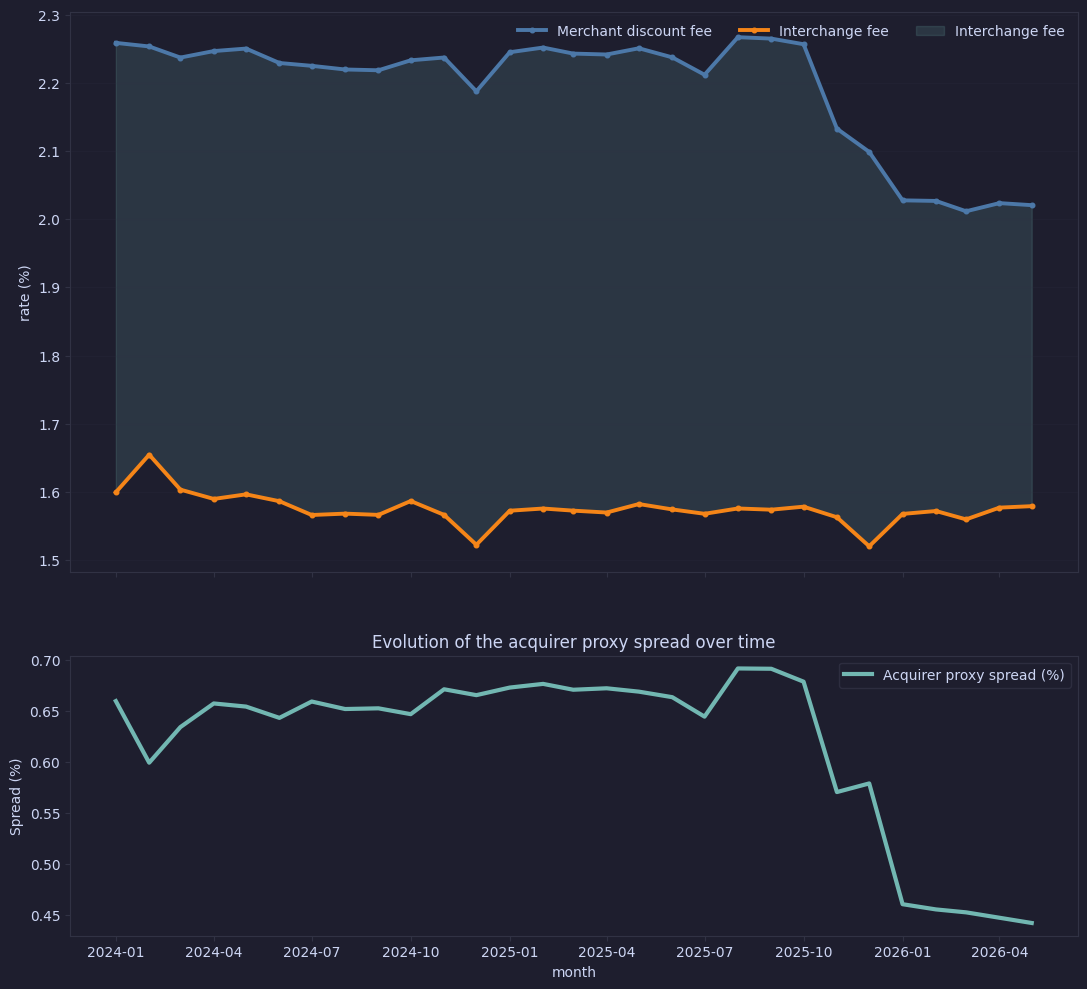

In [58]:
# plot

fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(13, 12),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

# Discount vs interchange:

ax1.plot(
    acquirer_market_fees["period"],
    acquirer_market_fees["tasa_descuento_total_adquirentes"],
    color="#4C78A8",
    linewidth=2.8,
    marker="o",
    markersize=3.3,
    label="Merchant discount fee",
)


ax1.plot(
    acquirer_market_fees["period"],
    acquirer_market_fees["tasa_intercambio_total"],
    color="#F58518",
    linewidth=2.8,
    marker="o",
    markersize=3.3,
    label="Interchange fee",
)

# we fill the space between the series (that is the spread)

ax1.fill_between(
    acquirer_market_fees["period"],
    acquirer_market_fees["tasa_descuento_total_adquirentes"],
    acquirer_market_fees["tasa_intercambio_total"],
    color="#72B7B2",
    alpha=0.16,
    label="Interchange fee",
)

ax1.set_ylabel("rate (%)")
ax1.legend(frameon=False, ncol=3, loc="upper right")  # para que se vea a la derecha
ax1.grid(axis="y", alpha=0.20)

# spread
ax2.plot(
    acquirer_market_fees["period"],
    acquirer_market_fees["acq_spread"],
    label="Acquirer proxy spread (%)",
    linewidth=3,
    color="#72B7B2",
)

ax2.set_title("Evolution of the acquirer proxy spread over time")
ax2.legend()
ax2.set_ylabel("Spread (%)")
ax2.set_xlabel("month")

ax2.spines["top"].set_visible(True)
ax2.spines["right"].set_visible(True)

plt.show()

- The weighted average merchant discount ratae charged by the acquirers has been declining sharply since october 2025, while the interchange fee remained around 1.6%

- That represnts a decrease of 0.68 to 0.44 of percentage point in the spread proxy , a compresion of 24 basis points

- This could suggest an increased pricing presaure in the market, further analysis is needed since the series are weighted avarage

- Nevertheless, given the methodology set by the BCRP, this also could be explained by a change in the transaction mix between merchants , segmetngs, channels or card tyeps

# Analysis per card type

In [59]:
acquirer_market_fees.head()

,period,tasa_descuento_total_adquirentes,tasa_descuento_tcredito_adquirentes,tasa_descuento_tdebito_adquirentes,tasa_descuento_tprepago_adquirentes,tasa_descuento_minoristas,tasa_descuento_farmacias,tasa_descuento_gasolineras,tasa_descuento_microcomercios,tasa_descuento_restaurantes,tasa_descuento_supermercados,tasa_descuento_transportes,tasa_descuento_otros_segmentos,tasa_intercambio_total,tasa_intercambio_tcredito,tasa_intercambio_tdebito,tasa_intercambio_prepago,tasa_intercambio_minoristas,tasa_intercambio_farmacias,tasa_intercambio_gasolineras,tasa_intercambio_microcomercios,tasa_intercambio_restaurantes,tasa_intercambio_supermercados,tasa_intercambio_transportes,tasa_intercambio_otros_segmentos,acq_spread
28,2024-01-01,2.26,2.45,2.10,1.87,2.13,2.61,1.74,2.55,2.84,1.74,2.48,2.34,1.60,1.88,1.38,1.44,1.49,1.44,1.24,1.00,2.57,1.03,1.77,1.68,0.66
27,2024-02-01,2.25,2.43,2.10,1.86,2.14,2.60,1.73,2.53,2.87,1.76,2.43,2.32,1.65,1.94,1.41,1.54,1.56,1.48,1.25,0.98,2.58,1.05,1.80,1.72,0.60
26,2024-03-01,2.24,2.41,2.09,1.82,2.11,2.49,1.74,2.50,2.89,1.76,2.52,2.32,1.60,1.89,1.36,1.47,1.48,1.45,1.26,1.00,2.60,1.02,1.83,1.69,0.63
25,2024-04-01,2.25,2.42,2.10,1.84,2.11,2.50,1.71,2.52,2.87,1.76,2.57,2.33,1.59,1.85,1.35,1.47,1.46,1.44,1.26,1.00,2.58,1.01,1.81,1.68,0.66
24,2024-05-01,2.25,2.41,2.11,1.85,2.14,2.55,1.75,2.63,2.84,1.75,2.55,2.32,1.60,1.87,1.36,1.49,1.48,1.45,1.27,1.00,2.58,1.02,1.80,1.68,0.65


In [60]:
acquirer_market_fees["acq_spread_tcredito"] = (
    acquirer_market_fees["tasa_descuento_tcredito_adquirentes"]
    - acquirer_market_fees["tasa_intercambio_tcredito"]
)
acquirer_market_fees["acq_spread_tdebito"] = (
    acquirer_market_fees["tasa_descuento_tdebito_adquirentes"]
    - acquirer_market_fees["tasa_intercambio_tdebito"]
)


acquirer_market_fees[
    ["period", "acq_spread_tcredito", "acq_spread_tdebito", "acq_spread"]
].tail(10)

,period,acq_spread_tcredito,acq_spread_tdebito,acq_spread
9,2025-08-01,0.56,0.79,0.69
8,2025-09-01,0.55,0.79,0.69
7,2025-10-01,0.55,0.78,0.68
6,2025-11-01,0.40,0.70,0.57
5,2025-12-01,0.43,0.67,0.58
4,2026-01-01,0.33,0.54,0.46
3,2026-02-01,0.33,0.54,0.46
2,2026-03-01,0.34,0.53,0.45
1,2026-04-01,0.32,0.54,0.45
0,2026-05-01,0.34,0.51,0.44


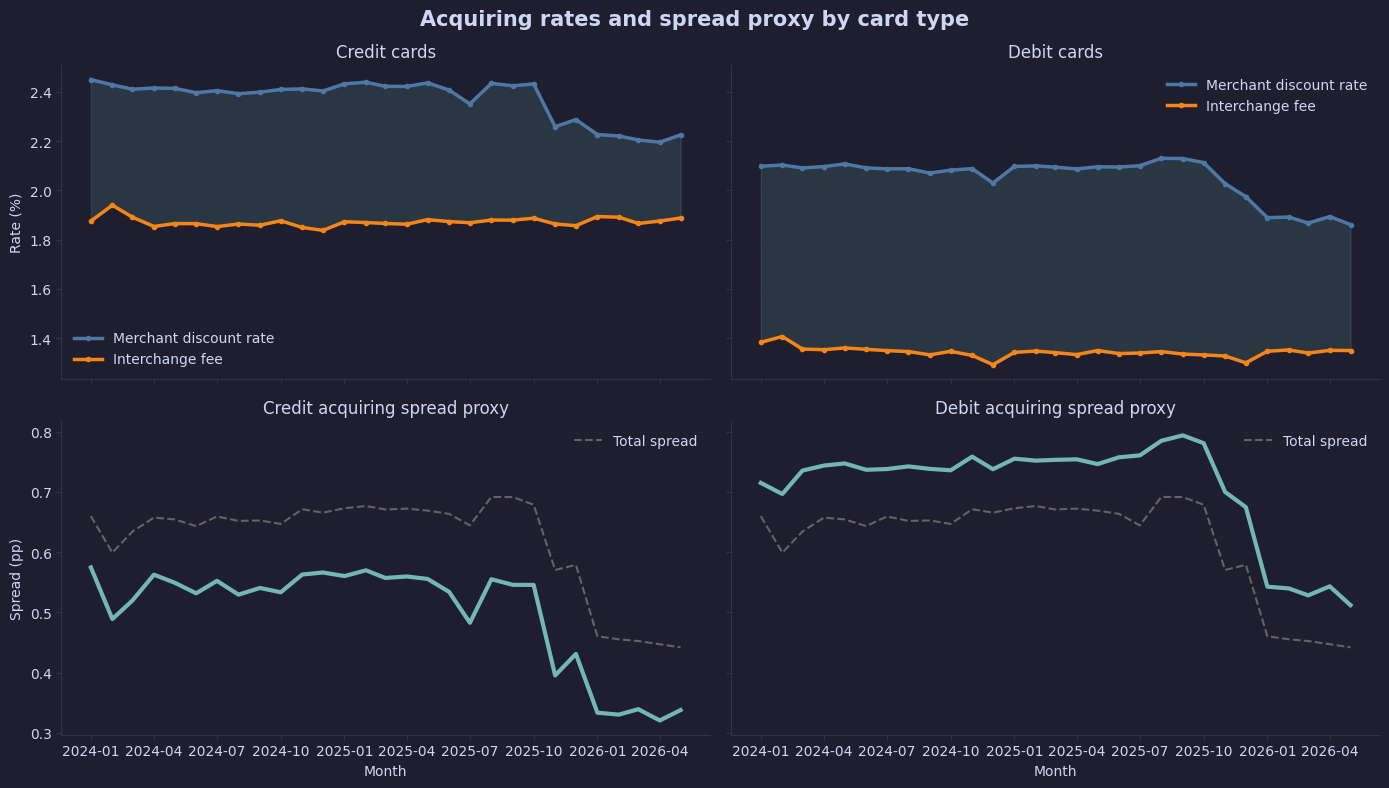

In [61]:
# plt
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 8),
    sharex=True,
    sharey="row",
)

ax1, ax2 = axes[0]
ax3, ax4 = axes[1]

discount_color = "#4C78A8"
interchange_color = "#F58518"
spread_color = "#72B7B2"

# --------------------------------
# Credit: discount vs interchange
# --------------------------------

ax1.plot(
    acquirer_market_fees["period"],
    acquirer_market_fees["tasa_descuento_tcredito_adquirentes"],
    color=discount_color,
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Merchant discount rate",
)

ax1.plot(
    acquirer_market_fees["period"],
    acquirer_market_fees["tasa_intercambio_tcredito"],
    color=interchange_color,
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Interchange fee",
)

ax1.fill_between(
    acquirer_market_fees["period"],
    acquirer_market_fees["tasa_intercambio_tcredito"],
    acquirer_market_fees["tasa_descuento_tcredito_adquirentes"],
    color=spread_color,
    alpha=0.16,
)

ax1.set_title("Credit cards")
ax1.set_ylabel("Rate (%)")
ax1.legend(frameon=False)

# -------------------------------
# Debit: discount vs interchange
# -------------------------------

ax2.plot(
    acquirer_market_fees["period"],
    acquirer_market_fees["tasa_descuento_tdebito_adquirentes"],
    color=discount_color,
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Merchant discount rate",
)

ax2.plot(
    acquirer_market_fees["period"],
    acquirer_market_fees["tasa_intercambio_tdebito"],
    color=interchange_color,
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Interchange fee",
)

ax2.fill_between(
    acquirer_market_fees["period"],
    acquirer_market_fees["tasa_intercambio_tdebito"],
    acquirer_market_fees["tasa_descuento_tdebito_adquirentes"],
    color=spread_color,
    alpha=0.16,
)

ax2.set_title("Debit cards")
ax2.legend(frameon=False)

# ------------------
# Credit card spread
# ------------------

ax3.plot(
    acquirer_market_fees["period"],
    acquirer_market_fees["acq_spread_tcredito"],
    color=spread_color,
    linewidth=3,
)

ax3.set_title("Credit acquiring spread proxy")
ax3.set_ylabel("Spread (pp)")
ax3.set_xlabel("Month")

# -----------------
# Debit card spread
# -----------------

ax4.plot(
    acquirer_market_fees["period"],
    acquirer_market_fees["acq_spread_tdebito"],
    color=spread_color,
    linewidth=3,
)

ax4.set_title("Debit acquiring spread proxy")
ax4.set_xlabel("Month")

# General formatting
for ax in axes.flat:
    ax.grid(axis="y", alpha=0.20)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Acquiring rates and spread proxy by card type",
    fontsize=15,
    fontweight="bold",
)

ax3.plot(
    acquirer_market_fees["period"],
    acquirer_market_fees["acq_spread"],
    color="gray",
    linewidth=1.5,
    linestyle="--",
    alpha=0.7,
    label="Total spread",
)

ax4.plot(
    acquirer_market_fees["period"],
    acquirer_market_fees["acq_spread"],
    color="gray",
    linewidth=1.5,
    linestyle="--",
    alpha=0.7,
    label="Total spread",
)

ax3.legend(frameon=False)
ax4.legend(frameon=False)


plt.tight_layout()
plt.show()

In [62]:
columns = {
    "Credit discount rate": "tasa_descuento_tcredito_adquirentes",
    "Credit interchange fee": "tasa_intercambio_tcredito",
    "Debit discount rate": "tasa_descuento_tdebito_adquirentes",
    "Debit interchange fee": "tasa_intercambio_tdebito",
}

for label, column in columns.items():

    volatility_bps = acquirer_market_fees[column].diff().std() * 100

    print(f"{label}: {volatility_bps:.2f} bps")

Credit discount rate: 4.23 bps
Credit interchange fee: 2.30 bps
Debit discount rate: 3.23 bps
Debit interchange fee: 2.10 bps


- The analysis shows a similar behavior within credit and debit cards
- It is important to note a slightly higher volatility observed in credit. This may reflect changes in merchant, channel, issuer, or transaction mix, but the aggregate data is insufficient to attribute it to a single cause

# Analysis per economic segment

In [63]:
acquirer_market_fees.head(3)

,period,tasa_descuento_total_adquirentes,tasa_descuento_tcredito_adquirentes,tasa_descuento_tdebito_adquirentes,tasa_descuento_tprepago_adquirentes,tasa_descuento_minoristas,tasa_descuento_farmacias,tasa_descuento_gasolineras,tasa_descuento_microcomercios,tasa_descuento_restaurantes,tasa_descuento_supermercados,tasa_descuento_transportes,tasa_descuento_otros_segmentos,tasa_intercambio_total,tasa_intercambio_tcredito,tasa_intercambio_tdebito,tasa_intercambio_prepago,tasa_intercambio_minoristas,tasa_intercambio_farmacias,tasa_intercambio_gasolineras,tasa_intercambio_microcomercios,tasa_intercambio_restaurantes,tasa_intercambio_supermercados,tasa_intercambio_transportes,tasa_intercambio_otros_segmentos,acq_spread,acq_spread_tcredito,acq_spread_tdebito
28,2024-01-01,2.26,2.45,2.10,1.87,2.13,2.61,1.74,2.55,2.84,1.74,2.48,2.34,1.60,1.88,1.38,1.44,1.49,1.44,1.24,1.00,2.57,1.03,1.77,1.68,0.66,0.57,0.72
27,2024-02-01,2.25,2.43,2.10,1.86,2.14,2.60,1.73,2.53,2.87,1.76,2.43,2.32,1.65,1.94,1.41,1.54,1.56,1.48,1.25,0.98,2.58,1.05,1.80,1.72,0.60,0.49,0.70
26,2024-03-01,2.24,2.41,2.09,1.82,2.11,2.49,1.74,2.50,2.89,1.76,2.52,2.32,1.60,1.89,1.36,1.47,1.48,1.45,1.26,1.00,2.60,1.02,1.83,1.69,0.63,0.52,0.74


In [64]:
acquirer_market_fees["acq_spread_minoristas"] = (
    acquirer_market_fees["tasa_descuento_minoristas"]
    - acquirer_market_fees["tasa_intercambio_minoristas"]
)
acquirer_market_fees["acq_spread_otros_segmentos"] = (
    acquirer_market_fees["tasa_descuento_otros_segmentos"]
    - acquirer_market_fees["tasa_intercambio_otros_segmentos"]
)


acquirer_market_fees[
    ["period", "acq_spread_minoristas", "acq_spread_otros_segmentos", "acq_spread"]
].tail(10)

,period,acq_spread_minoristas,acq_spread_otros_segmentos,acq_spread
9,2025-08-01,0.73,0.67,0.69
8,2025-09-01,0.75,0.66,0.69
7,2025-10-01,0.72,0.65,0.68
6,2025-11-01,0.60,0.56,0.57
5,2025-12-01,0.61,0.57,0.58
4,2026-01-01,0.43,0.49,0.46
3,2026-02-01,0.44,0.47,0.46
2,2026-03-01,0.42,0.48,0.45
1,2026-04-01,0.40,0.49,0.45
0,2026-05-01,0.42,0.46,0.44


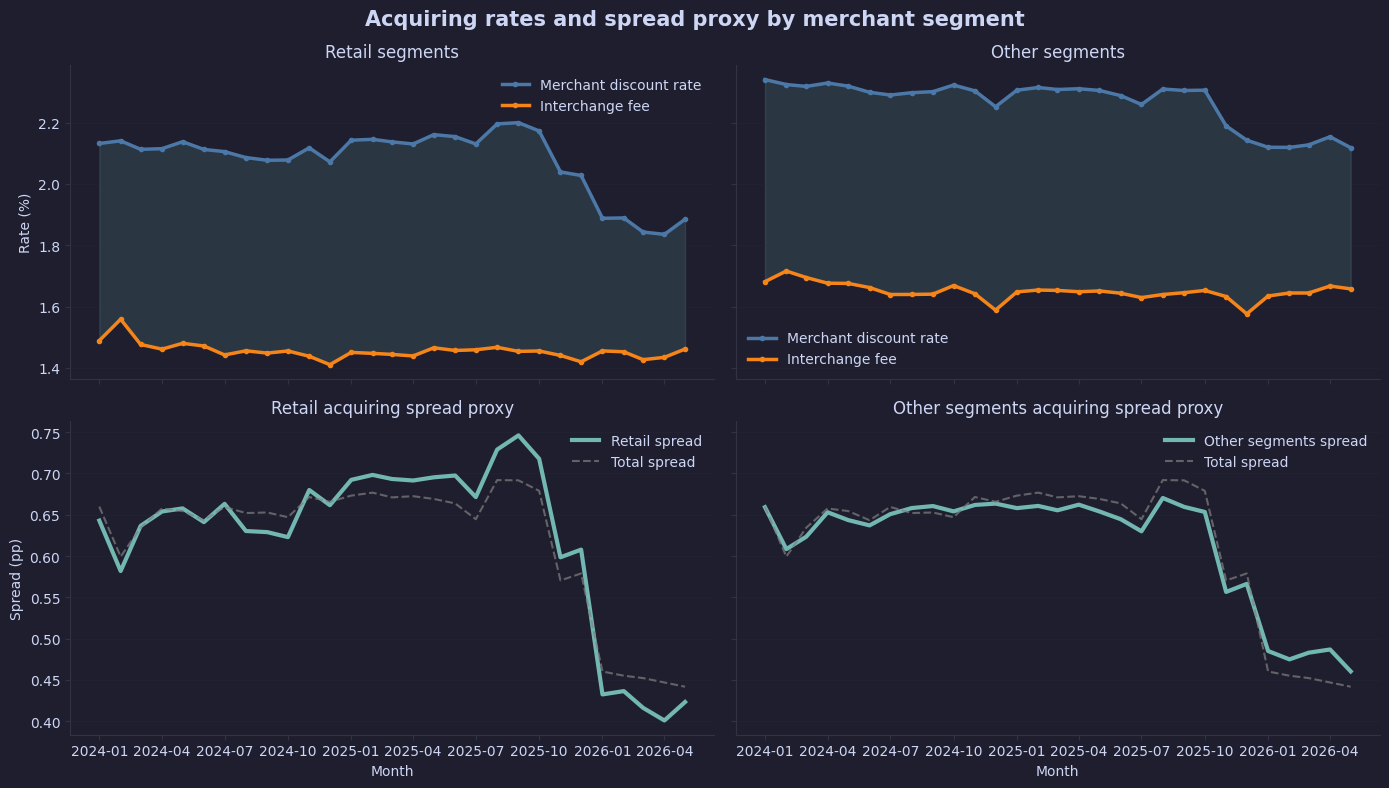

In [70]:
# Plot
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 8),
    sharex=True,
    sharey="row",
)

ax1, ax2 = axes[0]
ax3, ax4 = axes[1]

discount_color = "#4C78A8"
interchange_color = "#F58518"
spread_color = "#72B7B2"

# ---------------------------------------
# Retail: discount rate vs interchange
# ---------------------------------------

ax1.plot(
    acquirer_market_fees["period"],
    acquirer_market_fees["tasa_descuento_minoristas"],
    color=discount_color,
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Merchant discount rate",
)

ax1.plot(
    acquirer_market_fees["period"],
    acquirer_market_fees["tasa_intercambio_minoristas"],
    color=interchange_color,
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Interchange fee",
)

ax1.fill_between(
    acquirer_market_fees["period"],
    acquirer_market_fees["tasa_intercambio_minoristas"],
    acquirer_market_fees["tasa_descuento_minoristas"],
    color=spread_color,
    alpha=0.16,
)

ax1.set_title("Retail segments")
ax1.set_ylabel("Rate (%)")
ax1.legend(frameon=False)

# ---------------------------------------
# Other: discount rate vs interchange
# ---------------------------------------

ax2.plot(
    acquirer_market_fees["period"],
    acquirer_market_fees["tasa_descuento_otros_segmentos"],
    color=discount_color,
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Merchant discount rate",
)

ax2.plot(
    acquirer_market_fees["period"],
    acquirer_market_fees["tasa_intercambio_otros_segmentos"],
    color=interchange_color,
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Interchange fee",
)

ax2.fill_between(
    acquirer_market_fees["period"],
    acquirer_market_fees["tasa_intercambio_otros_segmentos"],
    acquirer_market_fees["tasa_descuento_otros_segmentos"],
    color=spread_color,
    alpha=0.16,
)

ax2.set_title("Other segments")
ax2.legend(frameon=False)

# -----------------------
# Retail segment spread
# -----------------------

ax3.plot(
    acquirer_market_fees["period"],
    acquirer_market_fees["acq_spread_minoristas"],
    color=spread_color,
    linewidth=3,
    label="Retail spread",
)

ax3.plot(
    acquirer_market_fees["period"],
    acquirer_market_fees["acq_spread"],
    color="gray",
    linewidth=1.5,
    linestyle="--",
    alpha=0.7,
    label="Total spread",
)

ax3.set_title("Retail acquiring spread proxy")
ax3.set_ylabel("Spread (pp)")
ax3.set_xlabel("Month")
ax3.legend(frameon=False)

# ----------------------
# Other segment spread
# ----------------------

ax4.plot(
    acquirer_market_fees["period"],
    acquirer_market_fees["acq_spread_otros_segmentos"],
    color=spread_color,
    linewidth=3,
    label="Other segments spread",
)

ax4.plot(
    acquirer_market_fees["period"],
    acquirer_market_fees["acq_spread"],
    color="gray",
    linewidth=1.5,
    linestyle="--",
    alpha=0.7,
    label="Total spread",
)

ax4.set_title("Other segments acquiring spread proxy")
ax4.set_xlabel("Month")
ax4.legend(frameon=False)

# General formatting
for ax in axes.flat:
    ax.grid(axis="y", alpha=0.20)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Acquiring rates and spread proxy by merchant segment",
    fontsize=15,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

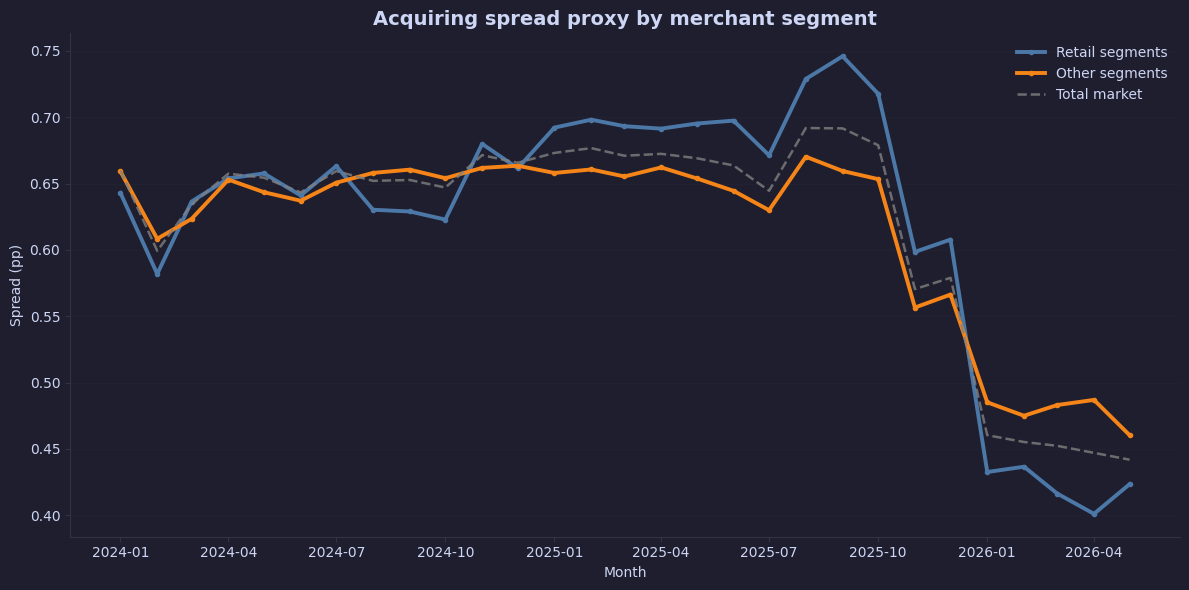

In [69]:
# Plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    acquirer_market_fees["period"],
    acquirer_market_fees["acq_spread_minoristas"],
    color="#4C78A8",
    linewidth=2.8,
    marker="o",
    markersize=3,
    label="Retail segments",
)

ax.plot(
    acquirer_market_fees["period"],
    acquirer_market_fees["acq_spread_otros_segmentos"],
    color="#F58518",
    linewidth=2.8,
    marker="o",
    markersize=3,
    label="Other segments",
)

# Aggregate spread as reference
ax.plot(
    acquirer_market_fees["period"],
    acquirer_market_fees["acq_spread"],
    color="gray",
    linewidth=1.8,
    linestyle="--",
    alpha=0.8,
    label="Total market",
)

ax.set_title(
    "Acquiring spread proxy by merchant segment",
    fontsize=14,
    fontweight="bold",
)

ax.set_ylabel("Spread (pp)")
ax.set_xlabel("Month")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.20)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

- The compresion of the acquiring spread is observed across both major merchant groups, this weaks the hypothesis that the decline is driven by a shift in the transaction composition (a fast increase in wholesalers than retal)

- The contraction seems to be stronger among retail segments , suggesting that the main triver may be found inside that category

# Analysis in the reatil segment

In [72]:
retail_segments = {
    "farmacias": "Pharmacies",
    "gasolineras": "Gas stations",
    "microcomercios": "Micro-businesses",
    "restaurantes": "Restaurants",
    "supermercados": "Supermarkets",
    "transportes": "Transportation",
}

for segment in retail_segments:

    acquirer_market_fees[f"acq_spread_{segment}"] = (
        acquirer_market_fees[f"tasa_descuento_{segment}"]
        - acquirer_market_fees[f"tasa_intercambio_{segment}"]
    )
spread_columns = [
    "period",
    *[f"acq_spread_{segment}" for segment in retail_segments],
]

acquirer_market_fees[spread_columns].tail(10)

,period,acq_spread_farmacias,acq_spread_gasolineras,acq_spread_microcomercios,acq_spread_restaurantes,acq_spread_supermercados,acq_spread_transportes
9,2025-08-01,1.09,0.60,1.77,0.23,0.74,0.56
8,2025-09-01,1.09,0.65,1.74,0.20,0.75,0.56
7,2025-10-01,1.14,0.48,1.73,0.20,0.77,0.51
6,2025-11-01,0.81,0.38,1.62,0.13,0.66,0.47
5,2025-12-01,0.83,0.55,1.51,-0.08,0.64,0.44
4,2026-01-01,0.34,0.33,1.45,-0.06,0.42,0.40
3,2026-02-01,0.34,0.32,1.45,-0.05,0.43,0.36
2,2026-03-01,0.34,0.32,1.44,-0.06,0.45,0.34
1,2026-04-01,0.32,0.32,1.33,-0.03,0.46,0.34
0,2026-05-01,0.42,0.32,1.47,-0.05,0.46,0.35


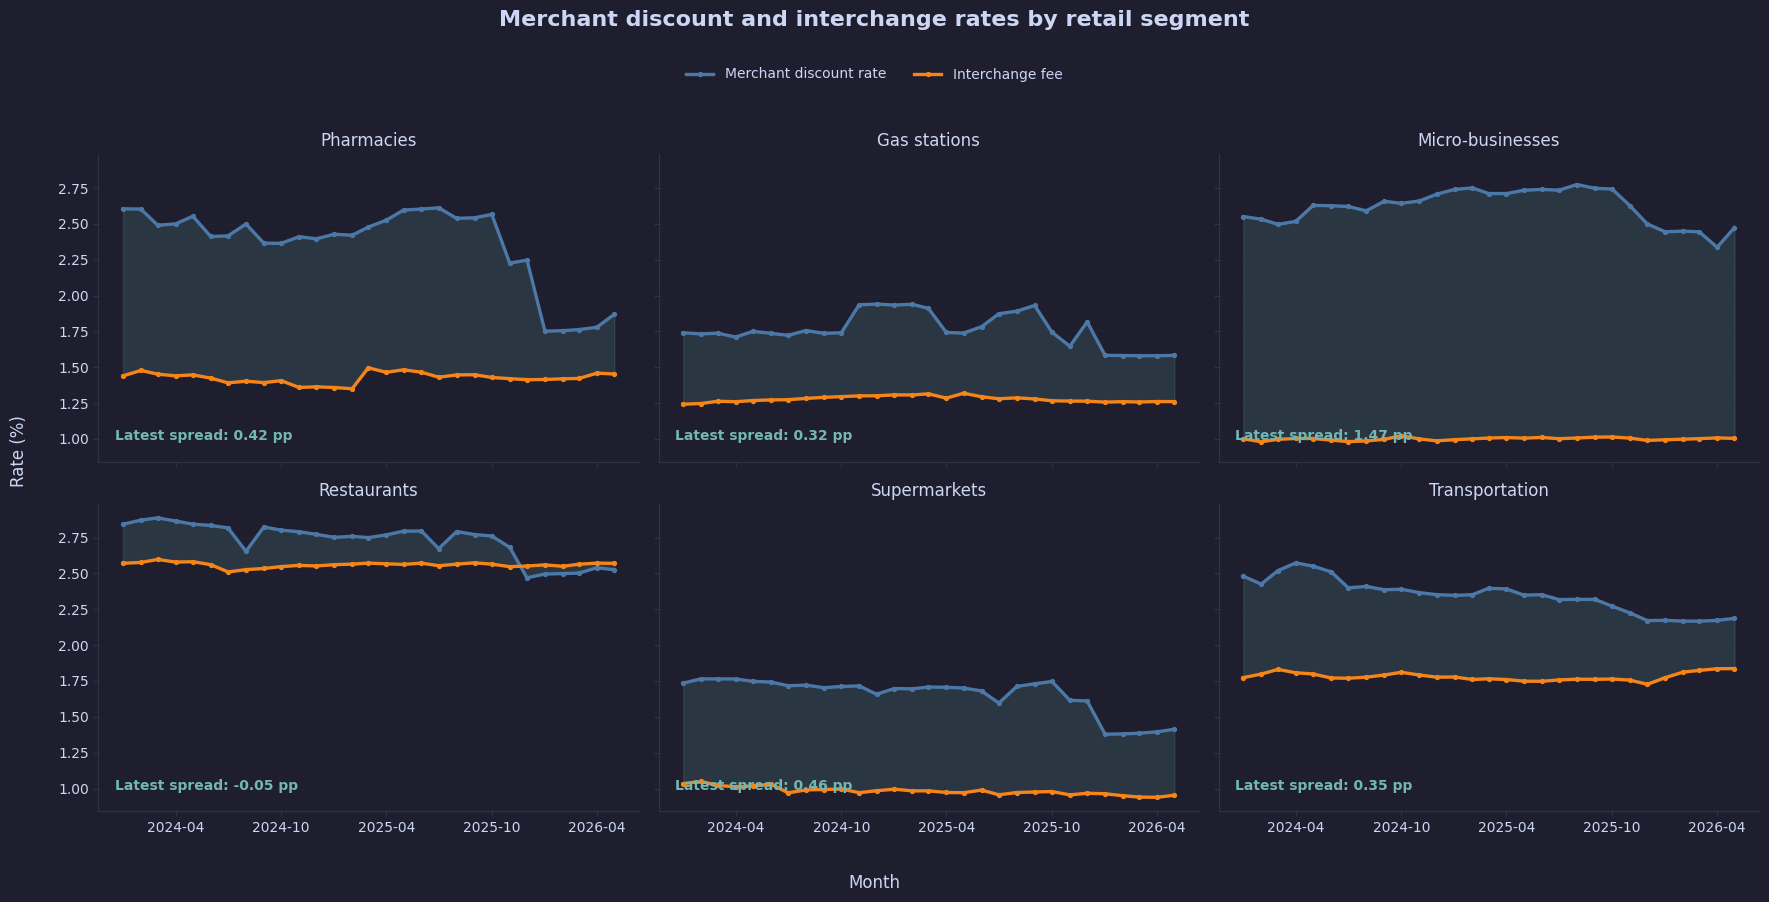

In [73]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18, 9),
    sharex=True,
    sharey=True,
)

discount_color = "#4C78A8"
interchange_color = "#F58518"
spread_color = "#72B7B2"

for ax, (segment, segment_label) in zip(
    axes.flat,
    retail_segments.items(),
):

    discount_column = f"tasa_descuento_{segment}"
    interchange_column = f"tasa_intercambio_{segment}"
    spread_column = f"acq_spread_{segment}"

    # Merchant discount rate
    ax.plot(
        acquirer_market_fees["period"],
        acquirer_market_fees[discount_column],
        color=discount_color,
        linewidth=2.4,
        marker="o",
        markersize=2.8,
        label="Merchant discount rate",
    )

    # Interchange fee
    ax.plot(
        acquirer_market_fees["period"],
        acquirer_market_fees[interchange_column],
        color=interchange_color,
        linewidth=2.4,
        marker="o",
        markersize=2.8,
        label="Interchange fee",
    )

    # Spread
    ax.fill_between(
        acquirer_market_fees["period"],
        acquirer_market_fees[interchange_column],
        acquirer_market_fees[discount_column],
        color=spread_color,
        alpha=0.16,
    )

    latest_spread = acquirer_market_fees[spread_column].dropna().iloc[-1]

    ax.text(
        0.03,
        0.07,
        f"Latest spread: {latest_spread:.2f} pp",
        transform=ax.transAxes,
        color=spread_color,
        fontweight="bold",
    )

    ax.set_title(segment_label)
    ax.grid(axis="y", alpha=0.20)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# Shared labels
fig.supylabel("Rate (%)")
fig.supxlabel("Month")

# One common legend
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.94),
)

fig.suptitle(
    "Merchant discount and interchange rates by retail segment",
    fontsize=16,
    fontweight="bold",
    y=0.99,
)

plt.tight_layout(rect=[0.02, 0.02, 1, 0.91])

plt.show()

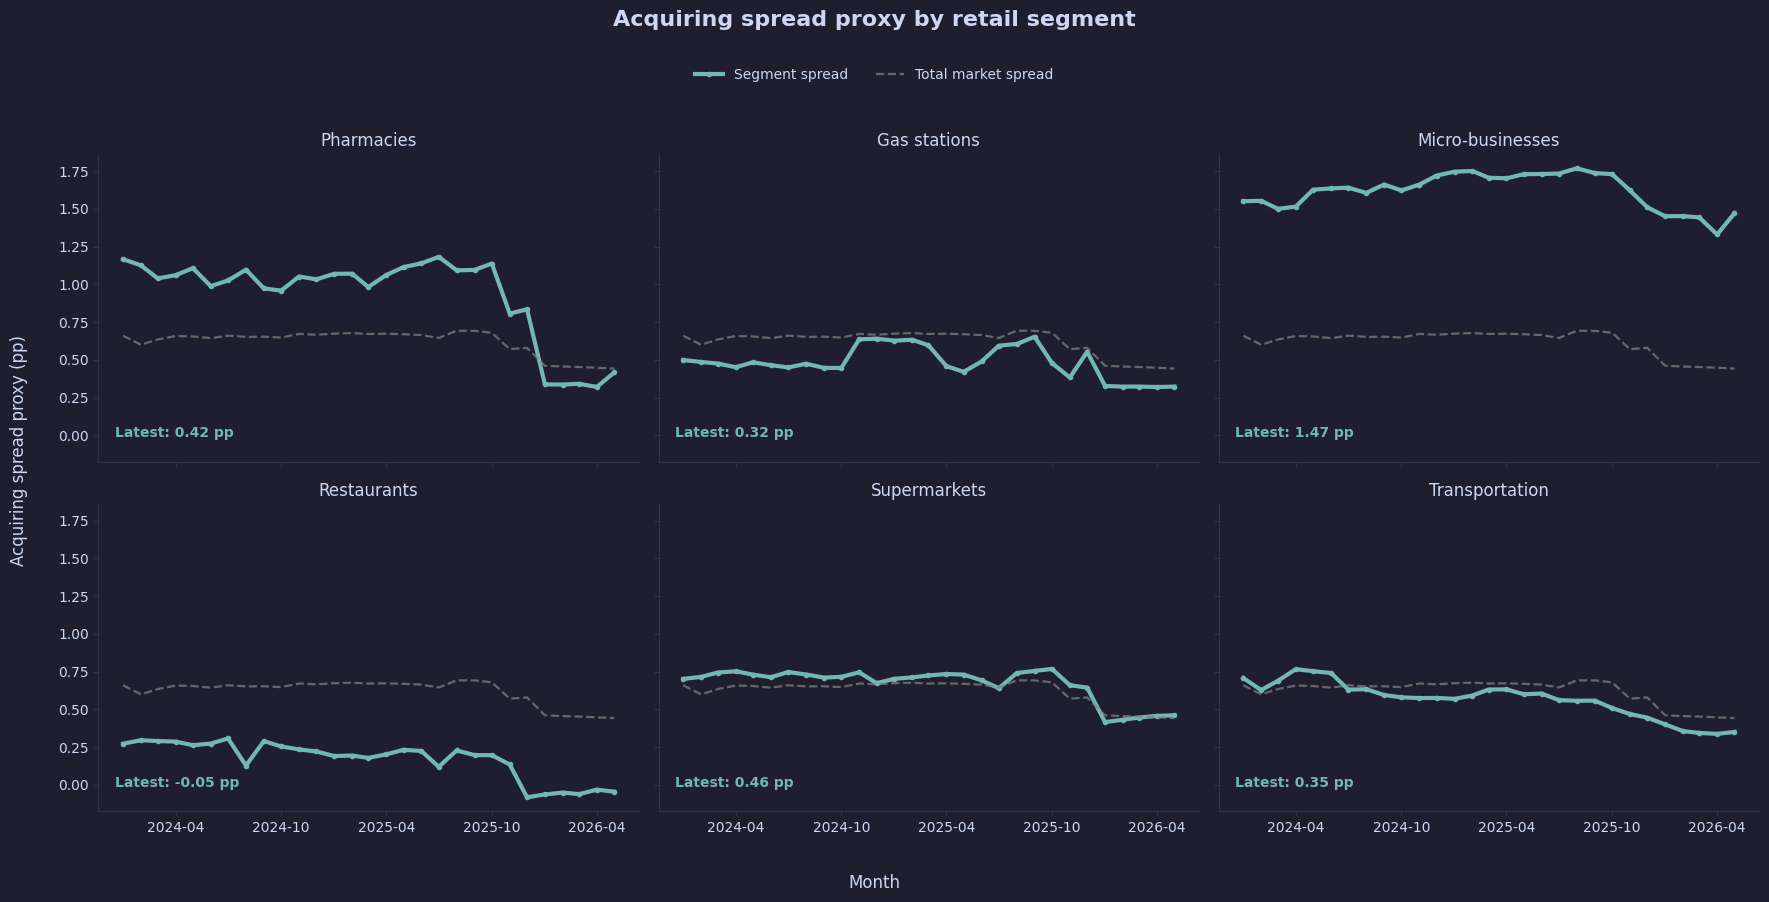

In [75]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18, 9),
    sharex=True,
    sharey=True,
)

spread_color = "#72B7B2"
total_color = "gray"

for ax, (segment, segment_label) in zip(
    axes.flat,
    retail_segments.items(),
):

    spread_column = f"acq_spread_{segment}"

    # Segment spread
    ax.plot(
        acquirer_market_fees["period"],
        acquirer_market_fees[spread_column],
        color=spread_color,
        linewidth=3,
        marker="o",
        markersize=3,
        label="Segment spread",
    )

    # Total market spread
    ax.plot(
        acquirer_market_fees["period"],
        acquirer_market_fees["acq_spread"],
        color=total_color,
        linewidth=1.6,
        linestyle="--",
        alpha=0.75,
        label="Total market spread",
    )

    latest_spread = acquirer_market_fees[spread_column].dropna().iloc[-1]

    ax.text(
        0.03,
        0.08,
        f"Latest: {latest_spread:.2f} pp",
        transform=ax.transAxes,
        color=spread_color,
        fontweight="bold",
    )

    ax.set_title(segment_label)
    ax.grid(axis="y", alpha=0.20)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# Shared labels
fig.supylabel("Acquiring spread proxy (pp)")
fig.supxlabel("Month")

# Common legend
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.94),
)

fig.suptitle(
    "Acquiring spread proxy by retail segment",
    fontsize=16,
    fontweight="bold",
    y=0.99,
)

plt.tight_layout(rect=[0.02, 0.02, 1, 0.91])

plt.show()

Severa conclusions

- Restaurants appear to have significantly tighter acquiring economics than other retail segments.
- Acquiring economics are structurally uneven across merchant segments; restaurants face interchange fees around 2.5%, leaving almost no observable acquiring spread, while micro merchatns exhibit interchange fees close to 1% and the widest spread proxy in the retail market (remember that the share of micromerchants in the total market is only around 5%)
- TODO: add more cnclusiones